# Assignment 6: Data Scraping
```
Course: ENV 700 - Environmental Data Exploration
Author: Student Name
Date: Fall 2026
```

This notebook accompanies the Python lessons on **Data Scraping**. We'll be scraping data from the North Carolina Department of Water Quality (NC DWQ). 

## 1. Setup
* Import packages: `requests`, `BeautifulSoup` (from `bs4`), `pandas` (as `pd`), `seaborn` (as `sns`) and any other packages you wish to use. 
* Set your Seaborn theme's style, context, and any runtime configurations you wish

In [1]:
#Import packages
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import calendar

#Set Seaborn theme
sns.set_theme(style='whitegrid', context='notebook')

## 2. Scraping Water Supply Data 
We will be scraping data from the NC DEQs Local Water Supply Planning website, specifically the Durham's 2025 Municipal Local Water Supply Plan (LWSP): 
 * Navigate to https://www.ncwater.org/WUDC/app/LWSP/search.php
 * Set the year to 2025
 * Scroll down and select the LWSP link next to Durham Municipality. 
 * Note the web address: <https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025>

---
### 2.1 Retrieve the website and parse it using BeautifulSoup

In [2]:
# 2.1 Retrieve the website and parse it using BeautifulSoup
response = requests.get('https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025')
the_website = BeautifulSoup(response.text, 'html.parser')

### 2.2 The data we want to collect are listed below:

* From the **1. System Information** section:
    - Water system name
    - Contact Person
    - Ownership
 
* From the **3. Water Supply Sources** section:
    - Maximum Day Use (MGD) - for each month

In the code chunk below scrape these values, assigning them to four separate variables.  
>HINT: The first value should be "`Durham`", the second "`Kieu Tran`", the third "`Municipality`", and the last should be a vector of 12 numeric values (represented as strings)".

In [3]:
# 2.2 Scrape the data into variables
# 1.2 Locate elements and read their text attributes into variables
water_system = [items.get_text(strip=True) for items in the_website.select('div+ table tr:nth-child(1) td:nth-child(2)')]
contact_person = [items.get_text(strip=True) for items in the_website.select('div+ table tr:nth-child(4) td:nth-child(2)')]
ownership = [items.get_text(strip=True) for items in the_website.select('div+ table tr:nth-child(2) td:nth-child(4)')]
max_day_use = [items.get_text(strip=True) for items in the_website.select('th~ td+ td')]


# attempt to pull date and use together
# max_day_use = [items.get_text(strip=True) for items in the_website.select('.fancy-table:nth-child(32) tr+ tr th , th~ td+ td')] 


print(water_system, contact_person, ownership,max_day_use)


['Durham'] ['Kieu Tran'] ['Municipality'] ['40.2400', '37.3800', '37.9100', '33.8100', '36.8400', '36.9000', '36.5300', '38.0400', '33.8000', '37.9500', '35.2000', '32.2000']


### 2.3 Construct a dataframe from the scraped data
Convert your scraped data into a dataframe. 
* This dataframe should have a column for each of the 4 variables scraped and a row for the month corresponding to the withdrawal data. 
* Note that you won't likely be able to scrape max water usage data in chronological order.
* Include columns for the month and year the data were collected. 
* Sort the data on year and month.
* Construct a datetime column from the year and month, assuming the day of the month will be the first. 

>🔥**TIP**: : To construct a list from a repeated set of values, use this approach:
>```python
>years_x6 = [2025] * 6
>print(years_x6)
>```

>🔥**TIP**: To construct a datetime column when you just the year and month, you can use the following:
>```python
>df['Date'] = pd.to_datetime({
>    "year": df['Year'],
>    "month": df['Month'],
>    "day": 1
>})
>```

In [10]:
# 2.3 Construct the dataframe from scraped data
water_system_12 = water_system *  12
contact_person_12 = contact_person* 12
ownership_12 = ownership * 12
year_12 = [2025] * 12


# how can i avoid this manually setting month order?
month_order = [1,5,9,2,6,10,3,7,11,4,8,12]

water_df = pd.DataFrame({
    'water_system_name': water_system_12,
    'contact_person': contact_person_12,
    'ownership': ownership_12,
    'max_daily_use': pd.to_numeric(max_day_use),
    'month': month_order,
    'year': year_12
})



water_df['date'] = pd.to_datetime({
    'year':water_df['year'],
    'month': water_df['month'],
    'day': 1
})

water_df = water_df.sort_values(by='date')

water_df




,water_system_name,contact_person,ownership,max_daily_use,month,year,date
0,Durham,Kieu Tran,Municipality,40.24,1,2025,2025-01-01
3,Durham,Kieu Tran,Municipality,33.81,2,2025,2025-02-01
6,Durham,Kieu Tran,Municipality,36.53,3,2025,2025-03-01
9,Durham,Kieu Tran,Municipality,37.95,4,2025,2025-04-01
1,Durham,Kieu Tran,Municipality,37.38,5,2025,2025-05-01
4,Durham,Kieu Tran,Municipality,36.84,6,2025,2025-06-01
7,Durham,Kieu Tran,Municipality,38.04,7,2025,2025-07-01
10,Durham,Kieu Tran,Municipality,35.20,8,2025,2025-08-01
2,Durham,Kieu Tran,Municipality,37.91,9,2025,2025-09-01
5,Durham,Kieu Tran,Municipality,36.90,10,2025,2025-10-01


### 2.4 Plot the data
* Create a line plot of the maximum daily withdrawals across the months for 2024
* Label the x-axis with month names or abbreviated month names. (Note, you may have to do some more wrangling...)

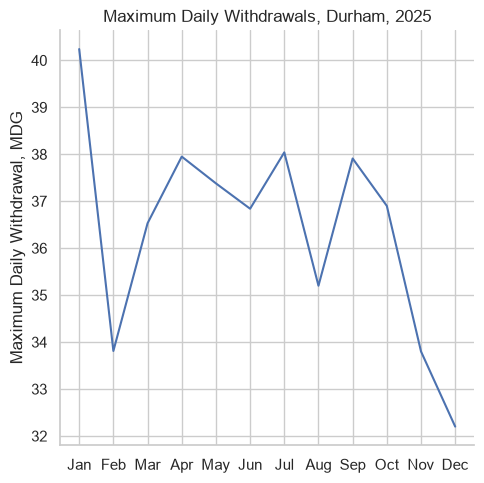

In [11]:
# 2.4 Plot the data

water_df['month_abb'] = pd.Categorical(
    values = water_df['date'].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:]

)
water_df

water_plot = sns.relplot(
    data=water_df,
    x='month_abb',
    y='max_daily_use',
    kind='line'
)
water_plot.set(
    title="Maximum Daily Withdrawals, Durham, 2025", 
    ylabel="Maximum Daily Withdrawal, MDG",
    xlabel=''
)



## 3. Automating the Scraping Process
### 3.1 Construct the scraping function
Note that the PWSID and the year appear in the web address for the page we scraped. Construct a function with two inputs, "PWSID" and "year", that:
  - Creates a URL pointing to the LWSP for that PWSID for the given year
  - Creates a website object and scrapes the data from that object (just as you did above)
  - Constructs a dataframe from the scraped data, mostly as you did above, but includes the PWSID and year provided as function inputs in the dataframe. 
  - Returns the dataframe as the function's output

In [ ]:
# 3.1 Create a scraping function
def scraper(pwsid, year):
    # define url
    url = f'https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid={pwsid}&year={year}/'
    print(url)
    # fetch and parse website
    response = requests.get(url)
    the_website = BeautifulSoup(response.text, 'html.parser')

    # extract data to list variables as above

    water_system = [items.get_text(strip=True) for items in the_website.select('div+ table tr:nth-child(1) td:nth-child(2)')]
    contact_person = [items.get_text(strip=True) for items in the_website.select('div+ table tr:nth-child(4) td:nth-child(2)')]
    ownership = [items.get_text(strip=True) for items in the_website.select('div+ table tr:nth-child(2) td:nth-child(4)')]
    max_day_use = [items.get_text(strip=True) for items in the_website.select('th~ td+ td')]

    print(water_system, contact_person, ownership, max_day_use)

    # 2.3 Construct the dataframe from scraped data
    water_system_12 = water_system *  12
    contact_person_12 = contact_person* 12
    ownership_12 = ownership * 12
    year_12 = year * 12


    # how can i avoid this manually setting month order?
    month_order = [1,5,9,2,6,10,3,7,11,4,8,12]

    water_df = pd.DataFrame({
        'water_system_name': water_system_12,
        'contact_person': contact_person_12,
        'ownership': ownership_12,
        'max_daily_use': pd.to_numeric(max_day_use),
        'month': month_order,
        'year': year_12
    })


    # add datetime column
    water_df['date'] = pd.to_datetime({
        'year':water_df['year'],
        'month': water_df['month'],
        'day': 1
    })

    water_df = water_df.sort_values(by='date')
   
    # add month abbreviation column
    water_df['month_abb'] = pd.Categorical(
    values = water_df['date'].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:]
    )

    return water_df


    



### 3.2 Fetch and plot data for Durham (PWSID=`03-32-010`) in 2020
* Use the function above to extract and plot max daily withdrawals for Durham (PWSID=`03-32-010`) for each month in 2020.
* Reveal the structure of your dataframe using the `info()` function. 
* Then create plot your data in a line plot as above: Max Usage by Month.

In [15]:
# 3.2.1 Scrape data for 03-32-010 in 2020 & display its structure
scraper('03-32-010', '2020')


https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2020/
[] [] [] []


ValueError: All arrays must be of the same length

In [ ]:
# 3.2.2 Plot the data

water_plot_2 = sns.relplot(
    data=water_df,
    x='month_abb',
    y='max_daily_use',
    kind='line'
)
water_plot.set(
    title="Maximum Daily Withdrawals, Durham, 2020", 
    ylabel="Maximum Daily Withdrawal, MDG",
    xlabel=''
)


### 3.3 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020

In [14]:
# 3.3.1 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020
scraper('03-92-020', '2020')

https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-92-020&year=2020/
[] [] [] []


ValueError: All arrays must be of the same length

In [ ]:
# 3.3.2 Plot the Cary data

water_plot_3 = sns.relplot(
    data=water_df,
    x='month_abb',
    y='max_daily_use',
    kind='line'
)
water_plot.set(
    title="Maximum Daily Withdrawals, Cary, 2020", 
    ylabel="Maximum Daily Withdrawal, MDG",
    xlabel=''
)



### 3.4 Examine monthy max discharge from 2020-2025
* Use list comprehension (or other methods) to produce a list of dataframes, one for each year in 2020 to 2025
* Concatenate these dataframes into a single one including data for all years
* Create a line plot of max monthly discharge across the full timespan (x-axis labels do not have to be months)

In [ ]:
# 3.4.1 Generate a list of the dataframes
years = [2020, 2021, 2022, 2023, 2024, 2025]
water_df_dict = {}

for year in years:
    df = scraper('03-92-020', year)
    water_df_dict[f"df_{year}"] = df
    

# 3.4.2 Combine them into a single dataframe
# init empty df
all_water = pd.DataFrame()

for value in water_df_dict.values():
    all_water = pd.concat([all_water, value], ignore_index=True)





In [ ]:
# 3.4.3 Plot
water_plot_3 = sns.relplot(
    data=all_water,
    x='date',
    y='max_daily_use',
    kind='line'
)
water_plot.set(
    title="Maximum Daily Withdrawals, Cary, 2020-2025 ", 
    ylabel="Maximum Daily Withdrawal, MDG",
    xlabel=''
)